In [404]:
import os
from enum import StrEnum

import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt, rcParams, colors, cm
import synapseclient
from scipy import stats
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list

rcParams["font.family"] = "Arial"
rcParams["font.size"] = 7

In [366]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse ID for the combined data table
COMBINED_TABLE_SYN_ID = "syn74775996"

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
    "combined_omics_data.arrow": "syn74775996"
}

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "cell_types"
)

In [367]:
# ensure figure directory exists
os.makedirs(FIGURE_DIR, exist_ok=True)

In [368]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.13.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.13.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



In [369]:
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/928073276.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/928073276.py:3: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/928073276.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776660:W_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/353/174033353/W_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/928073276.py:7: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776659:W_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/684/172720684/W_NPM1-WT_mut-cols.txt, skipping download.


In [370]:
def v2c(v): 
    return colors.to_hex(
        cm.ScalarMappable(
            norm=colors.Normalize(vmin=-1, vmax=1), 
            cmap="coolwarm"
        ).to_rgba(v)  # type: ignore
    )

---

In [371]:
tumor_gene_sets = {
    "tumor_hsc_like": [
        "NPTX2", "H1F0", "EMP1", "MEIS1", "CALCRL", "TPSD1", "TPT1", "CRHBP", "CLNK", "TSC22D1", 
        "DST", "NRIP1", "ABCB1", "GABRA4", "ZBTB20", "ABCA9", "TPSB2", "KMT2A", "FAM30A", "MEF2C", 
        "TMEM74", "PDZRN4", "ST3GAL1", "XIRP2", "RBPMS", "TMEM25", "C20orf203", "GNG11", "SLC6A13", "HOPX", 
        "CMTM2", "HIST1H2BK", "NPDC1", "SCRN1", "MECOM", "CXCL2", "CCS", "FAM74A4", "UMODL1-AS1", "CCDC18-AS1", 
        "TTLL10", "CFAP61", "PLCB4", "SPON1", "LINC01770", "CACNB4", "CCDC144NL-AS1", "RNF217", "ZPBP", "MPPED2",
    ],
    "tumor_prog_like": [
        "CDK6", "HSP90AB1", "SPINK2", "EEF1B2", "PCNP", "TAPT1-AS1", "HINT1", "LRRC75A-AS1", "DSE", "PEBP1", 
        "LOC107984974", "H2AFY", "EEF1A1", "SMIM24", "PSME1", "SOX4", "LINC01623", "EEF1G", "EBPL", "EIF4B", 
        "PARP1", "MEST", "TMEM70", "TFDP2", "ATP5G2", "NAP1L1", "MSI2", "TPM4", "SPN", "SELL", 
        "RACK1", "CTSC", "PRDX6", "EGFL7", "SNHG6", "NOP53", "MRPL57", "SELENOP", "CCDC152", "SRSF6", 
        "SNHG8", "B4GALT6", "HNRNPA1", "KIF2A", "HSH2D", "PTPRCAP", "NACA2", "PDLIM1", "CPA3", "GNPTAB",
    ],
    "tumor_gmp_like": [
        "PRTN3", "MPO", "CALR", "CLEC5A", "ELANE", "POU4F1", "TRH", "TSPOAP1", "CEBPE", "LINC01835", 
        "NUCB2", "CSF3R", "RUNX1T1", "CD38", "PLPPR3", "IGFBP2", "PRRT4", "SNHG5", "FABP5", "LOC100419170", 
        "CLEC11A", "SERPINB1", "AZU1", "FBN2", "HNRNPDL", "HSPB1", "RNA5-8S", "THSD7A", "C12orf57", "FGFR1", 
        "LPO", "MGST1", "C1QTNF4", "HMGN1", "SIPA1L2", "DDOST", "PTGIR", "GATM", "VAMP8", "FAM46A", 
        "VAMP5", "STAR", "ANKRD18A", "TM7SF3", "CCND1", "ROBO1", "GFI1", "DEFA4", "CERS6", "PTMA",
    ],
    "tumor_promono_like": [
        "DEFB1", "RNASE2", "MS4A3", "SERPINB10", "SESN3", "ZFR", "MRPL33", "CTSG", "SLC44A1", "SLPI", 
        "FUT4", "SRGN", "CD70", "PRLR", "PLD3", "LPL", "RETN", "TP53INP2", "HSPA5", "RNASE3", 
        "CCL23", "EMB", "ATP8B4", "CLU", "FAM107B", "KBTBD11", "CSTA", "ANKRD28", "PIWIL4", "RNVU1-6", 
        "F13A1", "PROK2", "IL31RA", "PLAC8", "ELF1", "EP400NL", "EAF2", "RFX8", "PTGFR", "JUN", 
        "FRMD3", "HOXB-AS3", "PHACTR3", "AK2", "ECRP", "DDIT3", "RFLNB", "FEZ1", "SERPINB2", "CDKN2A", 
    ],
    "tumor_mono_like": [
        "FCN1", "S100A12", "MAFB", "VCAN", "S100A9", "PLBD1", "SERPINA1", "BCL2A1", "THBS1", "PSAP", 
        "S100A8", "FPR1", "C5AR1", "CD14", "NAMPT", "VNN2", "CTSS", "DUSP1", "CEBPB", "CR1", 
        "NFKBIA", "SLC11A1", "LILRB3", "BCL6", "CYP1B1", "TNFAIP2", "MS4A10", "AQP9", "TLR4", "APOBEC3A", 
        "LRRK2", "CD163", "LRP1", "S100A10", "CD68", "MEGF9", "NCF2", "LOC643802", "IFNGR1", "FTL", 
        "SLC24A4", "CD300E", "CXCL8", "CLEC7A", "NEAT1", "CLEC4E", "CRISPLD2", "MEFV", "ACSL1", "NCF1", 
    ],
    "tumor_cdc_like": [
        "MRC1", "HLA-DRB5", "CST3", "SAMHD1", "NAPSB", "FCER1A", "HLA-DRB1", "JAML", "PKIB", "HLA-DRA", 
        "HLA-DRB6", "CPVL", "HLA-DPB1", "HLA-DQA1", "HLA-DPA1", "CLEC4A", "TMSB10", "CAP1", "HLA-DQB1", "CRIP1", 
        "CLEC10A", "GPX1", "ITGB7", "HLA-DQB2", "DBI", "FTH1P3", "ACTB", "HLA-DQA2", "S100B", "ALDH2", 
        "GABARAP", "LY86", "IGSF6", "HLA-DPB2", "CD74", "PAK1", "LGALS2", "CSF1R", "PALLD", "CCR2", 
        "GPR183", "GRB2", "EPS8", "COTL1", "DHRS9", "HLA-DMB", "HLA-DMA", "PYCARD", "LOC644936", "SH3BGRL3", 
    ]
}

In [372]:
cols = b_wt_cols + b_mut_cols + w_wt_cols + w_mut_cols

In [373]:
# re-map the gene sets from gene name to cell state
tumor_gene_sets_inv = {}
for k, vs in tumor_gene_sets.items():
    for v in vs:
        tumor_gene_sets_inv[v] = k

In [374]:
# map sample names to groups
sample_to_group = {}
for g, cs in {
    "b_wt": b_wt_cols,
    "b_mut": b_mut_cols,
    "w_wt": w_wt_cols,
    "w_mut": w_mut_cols
}.items():
    for c in cs:
        sample_to_group[c] = g

In [375]:
df = (
    pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["combined_omics_data.arrow"]).path)
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .select(
        "Gene",
        *cols
    )
    .fill_null(0.)
    .fill_nan(0.)
    .with_columns(
        (pl.exclude("Gene") + 1.)
        .log(2.)
    )
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/193019308.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["combined_omics_data.arrow"]).path)



[syn74775996:combined_omics_data.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/712/172719712/combined_omics_data.arrow, skipping download.


In [467]:
dfp = (
    pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["combined_omics_data.arrow"]).path)
    .filter(pl.col("Block") == "Proteomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .select(
        "Gene",
        *cols
    )
    .fill_null(0.)
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_20415/1709674396.py:2: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["combined_omics_data.arrow"]).path)



[syn74775996:combined_omics_data.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/712/172719712/combined_omics_data.arrow, skipping download.


In [468]:
dfp

Gene,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,18-00290,18-00408,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",-0.814061,1.816861,-0.736445,0.768784,0.0,0.0,0.0,0.0,0.0,0.0,-2.496953,-1.983407,0.010201,-1.536651,-0.283798,-0.846596,-1.185462,-1.886393,-2.255939,-0.86903,-0.994466,-1.629236,-1.651636,-1.338855,-0.991735,-1.073908,-0.793358,-0.6764,-0.1598,-0.778186,-1.008632,0.944915,0.032166,0.533066,0.168087,-0.579035,…,-0.103391,0.0,0.0,2.495934,0.622396,0.954504,-1.765944,-0.45448,-0.70102,-0.665767,0.771347,-0.548223,-0.349491,0.0,0.0,0.523952,1.214632,-0.930149,-0.015327,-0.283333,-1.490396,0.208721,-0.332556,-0.17198,-0.771102,0.0,1.425425,-0.613675,-1.960131,-0.244772,-0.620181,0.136426,1.35407,1.831792,-1.402024,0.774287,-0.166061
"""A2M""",0.997819,0.467943,-0.641917,0.529603,0.0,0.0,0.0,0.0,0.0,0.0,-2.635372,-1.055352,1.367216,-2.409141,0.079081,-1.279108,-0.981335,-0.121969,-2.367513,-1.941108,-0.805869,-0.727897,-1.407812,-2.539921,-0.460772,-0.007907,0.866745,0.033769,0.332937,-0.156613,-0.696728,1.231982,0.889241,1.371599,1.029027,-1.017979,…,-1.01622,0.362962,-0.961982,3.303742,-0.139976,0.742776,-0.644993,-0.357223,-0.401315,-0.142247,-0.170057,0.63802,0.221334,-1.198939,2.131375,0.903392,1.21773,-0.990183,1.007846,-0.290213,-2.032967,-0.150797,-0.150852,-0.130776,-0.809506,-1.401095,0.696236,1.708142,-1.648198,0.107448,-0.52108,-0.538384,0.955844,1.298137,-0.356208,1.57717,-0.653723
"""AAAS""",-2.337994,-2.247362,-1.660652,-1.990529,0.0,0.0,0.0,0.0,0.0,0.0,-2.588955,-2.086766,-2.077102,-1.964913,-2.384062,-2.54335,-1.518144,-1.66621,-2.318717,-1.898533,-1.846505,-1.631856,-1.104501,-1.876613,-1.805839,-1.297477,-1.598327,-1.094324,-1.962864,-0.85262,-0.075483,-0.893864,-1.574253,-0.749774,-1.047969,-1.17142,…,-1.528303,-2.502366,-1.933827,-2.960984,-2.009923,-0.743058,-1.892983,-0.408886,-3.00823,-1.132003,-2.74196,-0.858019,-1.690165,-1.795937,-0.300366,-0.439687,-0.879406,-1.456084,-1.800485,-2.003312,-2.437503,-0.881711,-1.290137,-1.593804,-1.74167,-2.125149,-0.610275,-3.250229,-2.799516,-0.933275,-0.699462,-1.583544,-0.96336,-1.00612,-2.400375,-1.664297,-2.129008
"""AACS""",-1.395308,-0.592229,-1.396367,-1.198349,0.0,0.0,0.0,0.0,0.0,0.0,-3.387757,-3.27876,-0.872215,-1.368821,-2.56183,-3.171764,-2.312599,-1.851794,-3.139611,-1.947569,-2.452907,-0.937198,-2.096114,-0.942515,-0.848268,-0.807739,-1.567493,-1.60971,-2.155845,-1.320333,-1.70331,-2.291172,-2.455354,-4.056117,-1.260883,-1.493818,…,-0.684526,-1.198332,-1.868509,-2.763673,-1.440268,-0.928548,-0.334524,0.869457,-0.951102,1.017977,-0.343664,-0.270661,-0.613057,-1.664651,0.871793,-0.062389,0.222108,-1.520839,-0.335503,-1.134018,-1.251056,-0.35589,0.525085,-0.947617,-0.969259,-2.440524,0.592322,-2.628,-1.381379,-0.293843,0.236105,-1.047586,0.058266,-0.066226,-0.734601,0.281598,-1.121212
"""AAGAB""",-2.336817,-0.90091,-1.730672,-1.75757,0.0,0.0,0.0,0.0,0.0,0.0,-3.924592,-3.891374,-2.380232,-2.630535,-2.063495,-2.507954,-3.430518,-2.726081,-2.95327,-2.185534,-2.632445,-2.157506,-1.622062,-1.750252,-2.019788,-1.781596,-1.904911,-2.203

In [376]:
pre_tx = (
    pl.concat([
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_hsc_like"][:30])),
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_prog_like"][:30])),
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_gmp_like"][:30])),
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_promono_like"][:30])),
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_mono_like"][:30])),
        df.filter(pl.col("Gene").is_in(tumor_gene_sets["tumor_cdc_like"][:30])),
    ])
)
# get rid of columns that are fully null
keep_cols = [
    col 
    for col in cols
    if pre_tx[col].sum() > 0
]

In [377]:
print(len(cols), len(keep_cols))

201 144


In [378]:
tx = (
    pre_tx
    .select(
        "Gene",
        (
            # pack the raw values into a list column
            pl.concat_list(
                pl.col(keep_cols)
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=keep_cols
            )
            .alias("packed")
        )
    )
    .unnest("packed")
)
tx

Gene,16-00538,16-01109,17-01060,C-05-0664,C-07-3682,C-10-1211,C-08-2091,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-07-2900,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-00-0552,C-10-0535,C-99-0901,C-03-2056,C-99-0740,C-10-0302,C-01-1599,C-08-2081,93-C-201,C-12-2943,…,17-00678,17-00676,17-00741,17-00770,17-00878,17-00881,17-00896,17-00901,18-00103,18-00101,18-00105,18-00190,18-00218,18-00290,18-00408,18-00414,19-00084,14-00126,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,16-00056,16-00504,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ST3GAL1""",0.886688,0.954187,0.03006,-0.347954,1.268268,-0.413309,-0.049328,-1.059175,-1.145961,1.710179,0.262033,-0.752535,-0.542206,0.022788,1.060055,-1.96881,-1.297198,2.162647,1.599796,1.109503,0.738087,0.028457,-0.956445,0.974331,0.375588,-0.087669,-0.87257,-0.596954,0.955559,-1.148565,0.55018,0.172541,1.11605,-1.506247,-0.041462,-4.179314,…,0.170114,0.009018,2.243512,1.552175,2.499628,-0.272501,0.492572,-1.234556,-0.019924,-0.513163,0.401887,-0.531078,0.632079,1.551174,0.451541,-0.347423,1.311963,-1.532358,-0.509061,0.186478,-0.765378,0.274713,-0.355086,-0.216995,-0.935139,-1.617587,-1.119681,-0.496616,0.509704,-0.077479,0.211301,-0.559683,-0.582713,0.754819,-0.392213,-0.517363,-0.155244
"""SLC6A13""",-0.30028,-0.163288,-0.117946,-0.41794,-0.173902,-0.41794,-0.240662,-0.079515,0.024989,-0.189923,-0.018978,-0.304532,-0.301856,-0.41794,-0.212911,-0.021707,-0.07353,-0.011483,-0.144752,4.688881,3.049715,-0.314581,-0.19361,0.11152,-0.090007,-0.219731,-0.11119,-0.090337,-0.208049,-0.314752,-0.107761,-0.208209,0.035885,-0.284779,0.050895,-0.41794,…,6.817012,-0.269476,0.157072,0.117452,0.011642,-0.41794,0.123024,-0.02335,-0.353829,-0.206879,-0.41794,-0.107763,-0.275798,-0.114463,-0.218867,-0.27031,0.257023,-0.258343,-0.073424,-0.255489,0.319062,-0.41794,-0.365331,0.574848,0.141746,0.210395,-0.183595,-0.187925,-0.377032,-0.199494,-0.162922,-0.210182,-0.220069,-0.363708,0.040685,-0.157964,0.258709
"""CALCRL""",-0.873608,-0.337231,0.486879,-1.085016,0.846682,-0.677535,-0.953503,-0.859445,-0.742789,-1.020886,1.298457,-0.86751,0.13516,-1.05462,-0.444658,0.29795,-0.941647,0.295862,-0.77447,-0.816742,-0.789841,0.379929,-0.892121,2.898741,1.82854,-0.125236,-0.363761,0.794443,0.52578,1.261674,1.580449,-0.18859,-0.9105,-0.622028,1.802458,-0.691814,…,-0.422362,1.242915,1.639373,-0.977859,3.314649,1.419646,1.902635,-1.071455,1.622237,-0.875807,2.017612,-0.145568,-0.333664,0.585968,1.198075,1.205391,1.357528,-0.714956,-0.303027,1.399924,-0.807513,0.173039,-0.567925,1.191018,0.904212,-0.537694,0.738921,-0.264585,-0.482723,0.92526,-0.64134,1.062737,-0.872232,-0.427785,0.556963,-0.874038,0.521988
"""MEF2C""",-1.26793,0.745241,0.229206,-1.359406,0.553845,-0.901614,0.514982,-1.044132,0.326692,0.725256,0.179489,-1.006114,1.435019,0.313099,-0.518385,0.375637,-1.411474,0.855666,-0.547562,1.999475,-0.546352,0.957326,-0.388066,1.904053,0.306956,0.837286,-0.581215,-0.397636,0.78644,-0.812859,-0.162364,0.442404,-0.546886,-0.963413,0.860889,-1.041511,…,1.312832,0.318276,1.52064,0.070158,1.208108,-0.584307,0.100146,1.429796,0.537979,-0.141911,0.499047,0.699583,1.436048,1.861513,0.968744,-0.145361,0.649075,-0.61103,-0.030542,0.691338,0.650819,-0.05657,-0.216936,0.684112,-0.332088,-0.053359,0.716421,-0.617411,-0.694296,0.023757,-1.524285,-0.124084,-1.516549,0.044257,-1.543597,0.420478,-0.979674
"""ABCB1""",-0.094249,0.123313,0.136611,0.581434,1.564952,0.478569,-0.509316,-0.293706,1.095094,1.543455,1.390291,-0.370061,1.729271,-1.115513,2.017453,1.005331,-0.294179,0.520543,0.179934,2

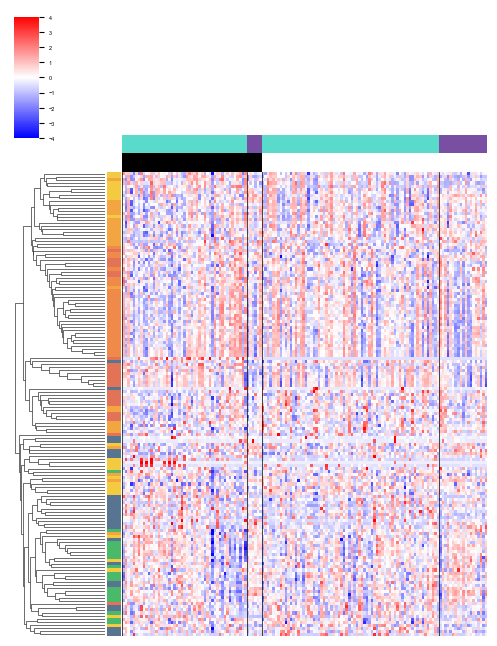

In [423]:
txp = (
    tx
    .to_pandas()
    .set_index("Gene")
)

col_colors = [
    ["#5ADACB" if c in b_wt_cols + w_wt_cols else "#794FA3" for c in txp.columns],
    ["#000000" if c in b_wt_cols + b_mut_cols else "#FFFFFF" for c in txp.columns],
    #[v2c(m) for m in txp.mean()]
]

x_lines = [0, len(col_colors[0])]
x_current = 0
cc1_, cc2_ = col_colors[0][0], col_colors[1][0]
for x, (cc1, cc2) in enumerate(zip(*col_colors)):
    if cc1 != cc1_ or cc2 != cc2_:
        x_lines.append(x)
        cc1_ = cc1
        cc2_ = cc2


# cell_state_color = {
#     "tumor_hsc_like": "#285234", 
#     "tumor_prog_like": "#357346", 
#     "tumor_gmp_like": "#3F9B57", 
#     "tumor_promono_like": "#42C164", 
#     "tumor_mono_like": "#3CE168", 
#     "tumor_cdc_like": "#14F851"
# }
cell_state_color = {
    "tumor_hsc_like": "#577590", 
    "tumor_prog_like": "#4AB969", 
    "tumor_gmp_like": "#F3CA40", 
    "tumor_promono_like": "#F2A541", 
    "tumor_mono_like": "#F08A4B", 
    "tumor_cdc_like": "#E27357"
}


row_colors = [
    cell_state_color[tumor_gene_sets_inv[g]]
    for g in txp.index
]

y_lines = [0, len(row_colors)]
y_current = 0
rc_ = row_colors[0]
for y, rc in enumerate(row_colors):
    if rc != rc_ :
        y_lines.append(y)
        rc_ = rc

# cluster the columns within each group
final_column_order = []
for group_name, cs in {
    "B_WT": set(b_wt_cols) & set(txp.columns),
    "B_MUT": set(b_mut_cols) & set(txp.columns),
    "W_WT": set(w_wt_cols) & set(txp.columns),
    "W_MUT": set(w_mut_cols) & set(txp.columns)
}.items():
    # Subset data to just this group's columns
    group_data = txp[list(cs)]
    
    # Perform hierarchical clustering on columns (transpose because linkage clusters rows)
    # Using 'ward' method and 'euclidean' distance metric
    Z = linkage(group_data.T, method='ward', metric='euclidean')
    
    # Extract the reordered column indices for this specific group
    ordered_idx = leaves_list(Z)
    
    # Map back to the original column names and append
    ordered_cols = [list(keep_cols)[i] for i in ordered_idx]

    final_column_order.extend(ordered_cols)

# cluster the rows within each group
ordered_indices = []
txp_ = txp.copy()
txp_["Group"] = [tumor_gene_sets_inv[g] for g in txp_.index]
for group_name, group_df in txp_.groupby("Group", sort=False):

    # Drop the categorical column to cluster based only on numeric features
    numeric_df = group_df.drop(columns=["Group"])

    # Compute hierarchical clustering linkage tree
    z = linkage(numeric_df, method='centroid', metric='euclidean')
    
    # Extract the optimal row order within this group
    local_order = leaves_list(z)
    #local_order = numeric_df.sum(axis=1).argsort()

    # Append the sorted labels to our master list
    ordered_indices.extend(numeric_df.iloc[local_order].index)

row_cluster = True
col_cluster = False

cg = sns.clustermap(
    txp.loc[ordered_indices],
    cmap="bwr",
    figsize=(5, 6.75),
    vmin=-4, 
    vmax=4,
    col_cluster=col_cluster,
    col_colors=col_colors,
    row_cluster=row_cluster,
    row_colors=row_colors,
    yticklabels=False
)
cg.ax_heatmap.set_xticks([])
cg.ax_heatmap.set_ylabel("")
if not row_cluster:
    for y in y_lines: 
        cg.ax_heatmap.axhline(y, c="k", lw=0.5)
if not col_cluster:
    for x in x_lines:
        cg.ax_heatmap.axvline(x, c="k", lw=0.5)
plt.savefig(
    os.path.join(FIGURE_DIR, f"full-tumor-gene-sets_cr_heatmap.pdf"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

---

In [380]:
sample_to_race = {}
sample_to_mut = {}
for sample in cols:
    if sample in b_wt_cols:
        sample_to_race[sample] = "black"
        sample_to_mut[sample] = "NPM1-"
    if sample in b_mut_cols:
        sample_to_race[sample] = "black"
        sample_to_mut[sample] = "NPM1+"
    if sample in w_wt_cols:
        sample_to_race[sample] = "white"
        sample_to_mut[sample] = "NPM1-"
    if sample in w_mut_cols:
        sample_to_race[sample] = "white"
        sample_to_mut[sample] = "NPM1+"

In [382]:
def tx_subset(gene_set, race, mut):
    return (
        tx
        .filter(
            pl.col("Gene")
            .is_in(tumor_gene_sets[gene_set])
        )
        .unpivot(
            on=[c for c in cols if c in tx.columns],
            index="Gene",
            variable_name="sample"
        )
        .drop("Gene")
        .with_columns(
            (
                pl.col("sample")
                .replace_strict(sample_to_race)
                .alias("race")
            ),
            (
                pl.col("sample")
                .replace_strict(sample_to_mut)
                .alias("mutation")
            )
        )
        .filter(
            (pl.col("race") == race)
            & (pl.col("mutation") == mut)
        )
        .group_by("sample", "race", "mutation")
        .agg(pl.col("value").mean())
    )

In [383]:
C = {
    ("black", "NPM1-"): "#53516A",
    ("black", "NPM1+"): "#E84855",
    ("white", "NPM1-"): "#3185FC",
    ("white", "NPM1+"): "#E3B505",
}

In [384]:
def swarm(
    ax,
    x_center, 
    values,
    c,
    sd=0.1
):
    x = np.random.normal(x_center, sd, size=len(values))
    ax.scatter(
        x, 
        values,
        marker=".",
        s=1,
        c=c
    )

gene_set='tumor_hsc_like'
pv_race=0.4008 pv_racem=0.2443
race='black' pv_mut=0.9610
race='white' pv_mut=0.5421
gene_set='tumor_prog_like'
pv_race=0.5639 pv_racem=0.5169
race='black' pv_mut=0.0002
race='white' pv_mut=0.1650
gene_set='tumor_gmp_like'
pv_race=0.7687 pv_racem=0.9726
race='black' pv_mut=0.1911
race='white' pv_mut=0.1476
gene_set='tumor_promono_like'
pv_race=0.0707 pv_racem=0.9574
race='black' pv_mut=0.2176
race='white' pv_mut=0.3601
gene_set='tumor_mono_like'
pv_race=0.7586 pv_racem=0.9092
race='black' pv_mut=0.7189
race='white' pv_mut=0.8035
gene_set='tumor_cdc_like'
pv_race=0.7324 pv_racem=0.2220
race='black' pv_mut=0.0489
race='white' pv_mut=0.2180


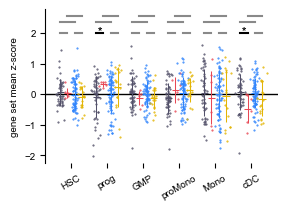

In [448]:
rcParams["font.size"] = 7

fig, ax = plt.subplots(
    figsize=(3, 2)
)

x_off = 0.2
bw = 0.1

ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene_set in enumerate([
    "tumor_hsc_like", "tumor_prog_like", "tumor_gmp_like",
    "tumor_promono_like", "tumor_mono_like", "tumor_cdc_like"
]):
    print(f"{gene_set=}")
    x_center = x_center + 1 - 1.5 * x_off
    # race p-value (NPM1-)
    pv_race = stats.ttest_ind(
        tx_subset(gene_set, "black", "NPM1-")["value"].to_list(),
        tx_subset(gene_set, "white", "NPM1-")["value"].to_list(),
        equal_var=False
    ).pvalue
    # race p-value (NPM1+)
    pv_racem = stats.ttest_ind(
        tx_subset(gene_set, "black", "NPM1+")["value"].to_list(),
        tx_subset(gene_set, "white", "NPM1+")["value"].to_list(),
        equal_var=False
    ).pvalue
    print(f"{pv_race=:.4f} {pv_racem=:.4f}")
    for race in ["black", "white"]:
        # mutation state p-value
        pv_mut = stats.ttest_ind(
            tx_subset(gene_set, race, "NPM1-")["value"].to_list(),
            tx_subset(gene_set, race, "NPM1+")["value"].to_list(),
            equal_var=False
        ).pvalue
        print(f"{race=} {pv_mut=:.4f}")
        for mut in ["NPM1-", "NPM1+"]:
            zs = tx_subset(gene_set, race, mut)["value"].to_list()
            ax.errorbar(
                x_center,
                np.mean(zs),
                yerr=np.std(zs),
                xerr=bw,
                ecolor=C[(race, mut)],
                elinewidth=0.75
            )
            # ax.scatter(
            #     x_center,
            #     np.mean(zs),
            #     marker="_",
            #     s=12,
            #     c="k",
            # )
            swarm(ax, x_center, zs, C[(race, mut)], sd=0.05)
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        yy = 2
        bc = "#898989"
        t = ""
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if pv_mut <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            yy + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [yy, yy],
            c=bc,
            ls="-",
            lw=1.5
        )
    # annotate statistically significant comparisons between black and white patients
    yyy = 2.35
    bc = "#898989"
    if pv_race <= 0.05:
        bc = "k"
    ax.plot(
        [x_center - 4 * x_off, x_center - 2 * x_off],
        [yyy, yyy],
        c=bc,
        ls="-",
        lw=1.5
    )
    yyy = 2.55
    bc = "#898989"
    if pv_racem <= 0.05:
        bc = "k"
    ax.plot(
        [x_center - 3 * x_off, x_center - x_off],
        [yyy, yyy],
        c=bc,
        ls="-",
        lw=1.5
    )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(tumor_gene_sets))])
ax.set_xticklabels(
    [
        "HSC", "prog", "GMP", "proMono", "Mono", "cDC"
    ], 
    rotation=30
)

ax.set_ylabel("gene set mean z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_tx_gene_set_averages.png"),
    dpi=400,
    #transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

tumor_prog_like
EIF4B PCNP SMIM24 HSP90AB1 CDK6 MEST DSE TFDP2 EEF1B2 EBPL SOX4 SPINK2 PARP1 MSI2 EEF1A1 HINT1 TMEM70 NAP1L1 SELL SPN


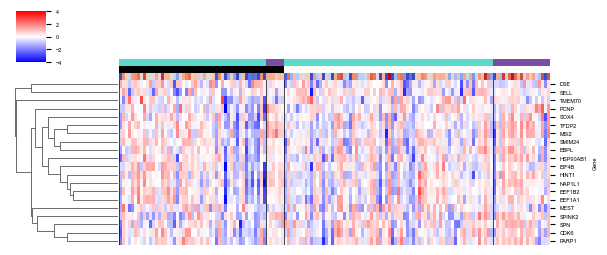

tumor_cdc_like
TMSB10 ACTB SAMHD1 CST3 CPVL ALDH2 CLEC4A CAP1 CLEC10A PKIB ITGB7 DBI S100B JAML HLA-DQB1 FCER1A HLA-DRB1 HLA-DRB5 HLA-DRA CRIP1 HLA-DPB1 HLA-DPA1 HLA-DQB2 GPX1 MRC1


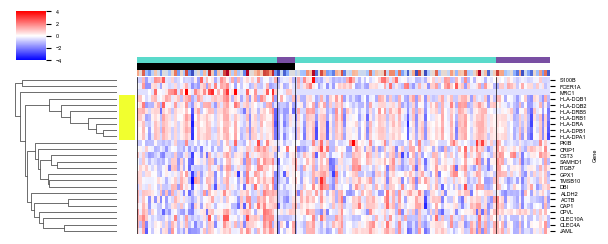

In [422]:
rcParams["font.size"] = 4



for gs in ["tumor_prog_like", "tumor_cdc_like"]:
    txp = (
        tx
        .filter(pl.col("Gene").is_in(tumor_gene_sets[gs]))
        .to_pandas()
        .set_index("Gene")
    )
    print(gs)
    print(" ".join(txp.index))

    col_colors = [
        ["#5ADACB" if c in b_wt_cols + w_wt_cols else "#794FA3" for c in txp.columns],
        ["#000000" if c in b_wt_cols + b_mut_cols else "#FFFFFF" for c in txp.columns],
        [v2c(m) for m in txp.mean()]
    ]

    x_lines = [0, len(col_colors[0])]
    x_current = 0
    cc1_, cc2_ = col_colors[0][0], col_colors[1][0]
    for x, (cc1, cc2) in enumerate(zip(*col_colors[:2])):
        if cc1 != cc1_ or cc2 != cc2_:
            x_lines.append(x)
            cc1_ = cc1
            cc2_ = cc2

    if gs == "tumor_cdc_like":
        rc = [
            "#F1FF2F" 
            if g.startswith("HLA") 
            else "#FFFFFF"
            for g in txp.index
        ]
    else:
        rc = None

    cg = sns.clustermap(
        txp,
        cmap="bwr",
        figsize=(6, (len(gs) + 10) / 20 * 2.25),
        vmin=-4, 
        vmax=4,
        col_cluster=False,
        col_colors=col_colors,
        row_cluster=True,
        yticklabels=True,
        row_colors=rc
    )

    if not col_cluster:
        for x in x_lines:
            cg.ax_heatmap.axvline(x, c="k", lw=0.5)
            
    cg.ax_heatmap.set_xticks([])

    plt.savefig(
        os.path.join(FIGURE_DIR, f"{gs}_heatmap.pdf"),
        dpi=400,
        bbox_inches="tight",
        transparent=True
    )
    plt.show()
    plt.close()

---

In [500]:
keep_cols2 = [
    col 
    for col in cols
    if df[col].sum() > 0
]

tx2 = (
    df
    .select(
        "Gene",
        (
            # pack the raw values into a list column
            pl.concat_list(
                pl.col(keep_cols2)
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=keep_cols2
            )
            .alias("packed")
        )
    )
    .unnest("packed")
)


In [501]:
keep_cols2p = [
    col 
    for col in cols
    if dfp[col].sum() != 0
]

tx2p = (
    dfp
    .select(
        "Gene",
        (
            # pack the raw values into a list column
            pl.concat_list(
                pl.col(keep_cols2p)
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=keep_cols2p
            )
            .alias("packed")
        )
    )
    .unnest("packed")
)

In [484]:
def tx2_subset(gene, race, mut, tx_or_txp):
    return (    
        (tx2 if tx_or_txp == "tx" else tx2p)
        .filter(pl.col("Gene") == gene)
        .unpivot(
            on=[c for c in cols if c in (tx2.columns if tx_or_txp == "tx" else tx2p.columns)],
            index="Gene",
            variable_name="sample"
        )
        .drop("Gene")
        .with_columns(
            (
                pl.col("sample")
                .replace_strict(sample_to_race)
                .alias("race")
            ),
            (
                pl.col("sample")
                .replace_strict(sample_to_mut)
                .alias("mutation")
            )
        )
        .filter(
            (pl.col("race") == race)
            & (pl.col("mutation") == mut)
        )
    )

In [673]:
def zscore_plot_specific_genes(
        genes,
        width,
        figname=None,
        bar_adjust=0.,
        tx_or_txp="tx"
):
    rcParams["font.size"] = 7

    fig, ax = plt.subplots(
        figsize=(width, 2)
    )

    x_off = 0.2
    bw = 0.1

    ax.axhline(c="k", lw=1., zorder=-1)

    for x_center, gene in enumerate(genes):
        print(f"{gene=}")
        x_center = x_center + 1 - 1.5 * x_off
        # race p-value (NPM1-)
        pv_race = stats.ttest_ind(
            tx2_subset(gene, "black", "NPM1-", tx_or_txp)["value"].to_list(),
            tx2_subset(gene, "white", "NPM1-", tx_or_txp)["value"].to_list(),
            equal_var=False
        ).pvalue
        # race p-value (NPM1+)
        pv_racem = stats.ttest_ind(
            tx2_subset(gene, "black", "NPM1+", tx_or_txp)["value"].to_list(),
            tx2_subset(gene, "white", "NPM1+", tx_or_txp)["value"].to_list(),
            equal_var=False
        ).pvalue
        print(f"{pv_race=:.4f} {pv_racem=:.4f}")
        for race in ["black", "white"]:
            # mutation state p-value
            pv_mut = stats.ttest_ind(
                tx2_subset(gene, race, "NPM1-", tx_or_txp)["value"].to_list(),
                tx2_subset(gene, race, "NPM1+", tx_or_txp)["value"].to_list(),
                equal_var=False
            ).pvalue
            print(f"{race=} {pv_mut=:.4f}")
            for mut in ["NPM1-", "NPM1+"]:
                zs = tx2_subset(gene, race, mut, tx_or_txp)["value"].to_list()
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C[(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C[(race, mut)], sd=0.05)
                x_center += x_off
            # annotate statistically significant comparisons between WT and mutant
            yy = bar_adjust + 3.5 + (0.1 if race == "white" else 0.)
            bc = "#898989"
            t = ""
            t_yoff = 0.2
            fs = 6
            fw = "normal"
            if pv_mut <= 0.05:
                t = "*"
                bc = "k"
                t_yoff = 0
                fs = 8
                fw = "bold"
            ax.text(
                x_center - 1.5 * x_off,
                yy + t_yoff,
                t,
                color=bc,
                ha="center",
                fontsize=fs,
                fontweight=fw
            )
            ax.plot(
                [x_center - 2 * x_off, x_center - x_off],
                [yy, yy],
                c=bc,
                ls="-",
                lw=1.5
            )
        # annotate statistically significant comparisons between black and white patients
        yyy = bar_adjust + 3.95
        bc = "#898989"
        if pv_race <= 0.05:
            bc = "k"
            ax.text(
                x_center - 3.75 * x_off,
                yyy,
                "*",
                color="k",
                ha="center",
                fontsize=8,
                fontweight="bold"
            )
        ax.plot(
            [x_center - 4 * x_off, x_center - 2 * x_off],
            [yyy, yyy],
            c=bc,
            ls="-",
            lw=1.5
        )
        yyy = bar_adjust + 4.15
        bc = "#898989"
        if pv_racem <= 0.05:
            bc = "k"
            ax.text(
                x_center - 1.25 * x_off,
                yyy,
                "*",
                color="k",
                ha="center",
                fontsize=8,
                fontweight="bold"
            )
        ax.plot(
            [x_center - 3 * x_off, x_center - x_off],
            [yyy, yyy],
            c=bc,
            ls="-",
            lw=1.5
        )

    for d in ["top", "right", "bottom"]:
        ax.spines[d].set_visible(False)

    ax.set_xticks([_ + 1 for _ in range(len(genes))])
    ax.set_xticklabels(
        genes,
        rotation=30
    )

    ax.set_ylabel("z-score")
    if figname is not None:
        plt.savefig(
            figname,
            dpi=400,
            transparent=True,
            bbox_inches="tight"
        )
    plt.show()
    plt.close()

gene='IRF8'
pv_race=0.0075 pv_racem=0.4486
race='black' pv_mut=0.3733
race='white' pv_mut=0.0409
gene='GATA1'
pv_race=0.5254 pv_racem=0.6478
race='black' pv_mut=0.4998
race='white' pv_mut=0.5218
gene='GATA2'
pv_race=0.5264 pv_racem=0.8578
race='black' pv_mut=0.6880
race='white' pv_mut=0.7330
gene='CEBPA'
pv_race=0.0292 pv_racem=0.2126
race='black' pv_mut=0.6249
race='white' pv_mut=0.1799
gene='RUNX1'
pv_race=0.5791 pv_racem=0.5885
race='black' pv_mut=0.6950
race='white' pv_mut=0.4960
gene='GFI1'
pv_race=0.0366 pv_racem=0.4882
race='black' pv_mut=0.5031
race='white' pv_mut=0.7240
gene='CEBPE'
pv_race=0.0247 pv_racem=0.9160
race='black' pv_mut=0.8209
race='white' pv_mut=0.2150
gene='CEBPD'
pv_race=0.0000 pv_racem=0.0013
race='black' pv_mut=0.0086
race='white' pv_mut=0.1367
gene='SPI1'
pv_race=0.0600 pv_racem=0.4209
race='black' pv_mut=0.2989
race='white' pv_mut=0.2255


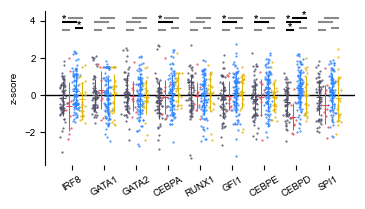

gene='IRF8'
pv_race=0.0075 pv_racem=0.4486
race='black' pv_mut=0.3733
race='white' pv_mut=0.0409
gene='GATA1'
pv_race=0.5254 pv_racem=0.6478
race='black' pv_mut=0.4998
race='white' pv_mut=0.5218
gene='GATA2'
pv_race=0.5264 pv_racem=0.8578
race='black' pv_mut=0.6880
race='white' pv_mut=0.7330
gene='CEBPA'
pv_race=0.0292 pv_racem=0.2126
race='black' pv_mut=0.6249
race='white' pv_mut=0.1799
gene='RUNX1'
pv_race=0.5791 pv_racem=0.5885
race='black' pv_mut=0.6950
race='white' pv_mut=0.4960
gene='GFI1'
pv_race=0.0366 pv_racem=0.4882
race='black' pv_mut=0.5031
race='white' pv_mut=0.7240
gene='CEBPE'
pv_race=0.0247 pv_racem=0.9160
race='black' pv_mut=0.8209
race='white' pv_mut=0.2150
gene='CEBPD'
pv_race=0.0000 pv_racem=0.0013
race='black' pv_mut=0.0086
race='white' pv_mut=0.1367
gene='SPI1'
pv_race=0.0600 pv_racem=0.4209
race='black' pv_mut=0.2989
race='white' pv_mut=0.2255


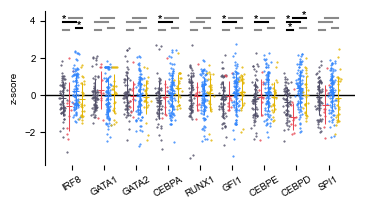

In [674]:
for t in ["tx", "txp"]:
    zscore_plot_specific_genes(
        [
            # neutrophil transcription factors
            "IRF8", "GATA1", "GATA2","CEBPA",   # GMP
            "RUNX1", "GFI1",                    # GMP + preNeu
            "CEBPE",                            # preNeu + immNeu
            "CEBPD", "SPI1"                     # matNeu
        ], 
        4, 
        figname=os.path.join(FIGURE_DIR, f"neutrophil_tfs_{t}_zscores.png"),
        tx_or_txp="txp"
    )

gene='HLA-DRB1'
pv_race=0.3882 pv_racem=0.3651
race='black' pv_mut=0.0489
race='white' pv_mut=0.2873
gene='HLA-DRB5'
pv_race=0.9097 pv_racem=0.0717
race='black' pv_mut=0.0082
race='white' pv_mut=0.0411
gene='HLA-DRA'
pv_race=0.7268 pv_racem=0.3992
race='black' pv_mut=0.0565
race='white' pv_mut=0.0995
gene='HLA-DPB1'
pv_race=0.5539 pv_racem=0.3582
race='black' pv_mut=0.0076
race='white' pv_mut=0.0830
gene='HLA-DPA1'
pv_race=0.6409 pv_racem=0.3768
race='black' pv_mut=0.0362
race='white' pv_mut=0.1315


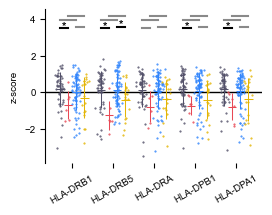

gene='HLA-DRB1'
pv_race=0.0044 pv_racem=0.1452
race='black' pv_mut=0.1594
race='white' pv_mut=0.1530
gene='HLA-DRB5'
pv_race=0.0010 pv_racem=0.0313
race='black' pv_mut=0.3309
race='white' pv_mut=0.7176
gene='HLA-DRA'
pv_race=0.0068 pv_racem=0.2085
race='black' pv_mut=0.1611
race='white' pv_mut=0.0583
gene='HLA-DPB1'
pv_race=0.0815 pv_racem=0.0676
race='black' pv_mut=0.0437
race='white' pv_mut=0.1148
gene='HLA-DPA1'
pv_race=0.0086 pv_racem=0.2244
race='black' pv_mut=0.0668
race='white' pv_mut=0.0049


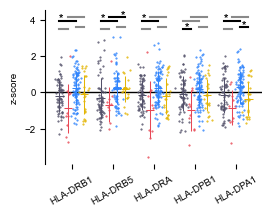

In [675]:
for t in ["tx", "txp"]:
    zscore_plot_specific_genes(
        [
            # MHC class II proteins
            "HLA-DRB1", "HLA-DRB5", "HLA-DRA", "HLA-DPB1", "HLA-DPA1",
        ], 
        2.8,
        figname=os.path.join(FIGURE_DIR, f"mhc_clas_II_{t}_zscores.png"),
        tx_or_txp=t
    )

gene='CD38'
pv_race=0.0502 pv_racem=0.0900
race='black' pv_mut=0.2028
race='white' pv_mut=0.4425
gene='CD33'
pv_race=0.0054 pv_racem=0.1592
race='black' pv_mut=0.8888
race='white' pv_mut=0.2680
gene='CXCR4'
pv_race=0.5035 pv_racem=0.4136
race='black' pv_mut=0.5964
race='white' pv_mut=0.9483
gene='CD101'
pv_race=0.6494 pv_racem=0.6276
race='black' pv_mut=0.3734
race='white' pv_mut=0.2993
gene='CD44'
pv_race=0.1065 pv_racem=0.2573
race='black' pv_mut=0.9485
race='white' pv_mut=0.6746


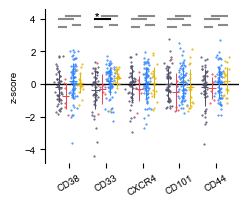

gene='CD38'
pv_race=0.0041 pv_racem=0.2239
race='black' pv_mut=0.4504
race='white' pv_mut=0.1916
gene='CD33'
pv_race=0.0108 pv_racem=0.3451
race='black' pv_mut=0.2800
race='white' pv_mut=0.3808
gene='CXCR4'
pv_race=0.0058 pv_racem=0.2154
race='black' pv_mut=0.6660
race='white' pv_mut=0.5567
gene='CD101'
pv_race=0.0000 pv_racem=0.0266
race='black' pv_mut=0.1766
race='white' pv_mut=0.1879
gene='CD44'
pv_race=0.0012 pv_racem=0.1105
race='black' pv_mut=0.8235
race='white' pv_mut=0.8271


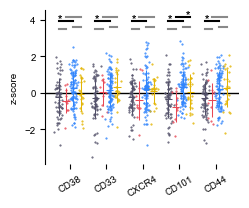

In [676]:
for t in ["tx", "txp"]: 
    zscore_plot_specific_genes(
        [
            # neutrophil cell surface markers
            "CD38",     # preNeu
            "CD33",     # preNeu + immNeu + matNeu
            "CXCR4",    # immNeu
            "CD101",    # immNeu + matNeu
            "CD44",     # matNeu
        ], 
        2.5,
        figname=os.path.join(FIGURE_DIR, f"neutrophil_cell-surface_{t}_zscores.png"),
        tx_or_txp=t
    )

gene='HEXA'
pv_race=0.0017 pv_racem=0.9097
race='black' pv_mut=0.1714
race='white' pv_mut=0.7672
gene='PRSS57'
pv_race=0.9995 pv_racem=0.6294
race='black' pv_mut=0.0915
race='white' pv_mut=0.3537
gene='PRTN3'
pv_race=0.2945 pv_racem=0.3265
race='black' pv_mut=0.7317
race='white' pv_mut=0.9674
gene='CTSG'
pv_race=0.3870 pv_racem=0.0169
race='black' pv_mut=0.0002
race='white' pv_mut=0.0949
gene='MPO'
pv_race=0.7125 pv_racem=0.9851
race='black' pv_mut=0.5525
race='white' pv_mut=0.3880
gene='ELANE'
pv_race=0.3633 pv_racem=0.3424
race='black' pv_mut=0.6379
race='white' pv_mut=0.8583
gene='CTSC'
pv_race=0.0055 pv_racem=0.4228
race='black' pv_mut=0.6582
race='white' pv_mut=0.7343
gene='HEXB'
pv_race=0.0381 pv_racem=0.3401
race='black' pv_mut=0.2308
race='white' pv_mut=0.1330


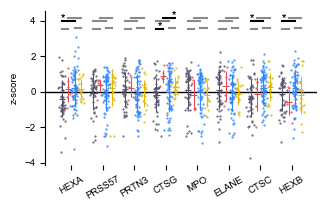

gene='HEXA'
pv_race=0.0003 pv_racem=0.5758
race='black' pv_mut=0.3733
race='white' pv_mut=0.8788
gene='PRSS57'
pv_race=0.1293 pv_racem=0.3513
race='black' pv_mut=0.0280
race='white' pv_mut=0.5054
gene='PRTN3'
pv_race=0.4478 pv_racem=0.1756
race='black' pv_mut=0.0439
race='white' pv_mut=0.2465
gene='CTSG'
pv_race=0.0004 pv_racem=0.3199
race='black' pv_mut=0.5312
race='white' pv_mut=0.8288
gene='MPO'
pv_race=0.9652 pv_racem=0.6416
race='black' pv_mut=0.2841
race='white' pv_mut=0.3816
gene='ELANE'
pv_race=0.3019 pv_racem=0.8366
race='black' pv_mut=0.8572
race='white' pv_mut=0.4508
gene='CTSC'
pv_race=0.0062 pv_racem=0.3138
race='black' pv_mut=0.7912
race='white' pv_mut=0.5859
gene='HEXB'
pv_race=0.0000 pv_racem=0.3619
race='black' pv_mut=0.7270
race='white' pv_mut=0.6079


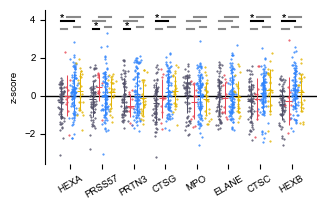

In [677]:
for t in ["tx", "txp"]: 
    zscore_plot_specific_genes(
        [
            # neutrophil granule proteins
            # primary/azurophil 
            "HEXA",                                     # GMP
            "PRSS57", "PRTN3", "CTSG", "MPO", "ELANE",  # GMP + preNeu
            "CTSC",                                     # GMP + immNeu
            "HEXB"                                      # preNeu + immNeu
        ], 
        3.5,
        figname=os.path.join(FIGURE_DIR, f"neutrophil_granule_primary_{t}_zscores.png"),
        tx_or_txp=t
    )

[WARNING] /Users/dylan.ross/Projects/AML_outcome_disparities/260711_neutrophils-and-cell-state/sec_4_cell_state/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,

[WARNING] /Users/dylan.ross/Projects/AML_outcome_disparities/260711_neutrophils-and-cell-state/sec_4_cell_state/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)

[WARNING] /Users/dylan.ross/Projects/AML_outcome_disparities/260711_neutrophils-and-cell-state/sec_4_cell_state/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

[WARNING] /Users/dylan.ross/Projects/AML_outcome_disparities/26071

gene='STOM'
pv_race=0.3387 pv_racem=0.3805
race='black' pv_mut=0.9041
race='white' pv_mut=0.2777
gene='LTF'
pv_race=nan pv_racem=nan
race='black' pv_mut=nan
race='white' pv_mut=nan
gene='CAMP'
pv_race=0.1292 pv_racem=0.9794
race='black' pv_mut=0.2045
race='white' pv_mut=0.2624
gene='CYBB'
pv_race=0.2136 pv_racem=0.7368
race='black' pv_mut=0.4210
race='white' pv_mut=0.1645
gene='CEACAM1'
pv_race=0.7337 pv_racem=0.5822
race='black' pv_mut=0.6882
race='white' pv_mut=0.0741
gene='LCN2'
pv_race=0.3471 pv_racem=0.0092
race='black' pv_mut=0.2445
race='white' pv_mut=0.2059
gene='LYZ'
pv_race=0.0911 pv_racem=0.7014
race='black' pv_mut=0.5938
race='white' pv_mut=0.1515
gene='HP'
pv_race=0.8402 pv_racem=0.9598
race='black' pv_mut=0.3546
race='white' pv_mut=0.0817


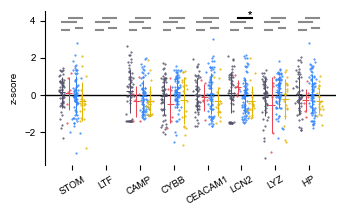

gene='STOM'
pv_race=0.5232 pv_racem=0.4639
race='black' pv_mut=0.1323
race='white' pv_mut=0.4635
gene='LTF'
pv_race=0.0105 pv_racem=0.0095
race='black' pv_mut=0.0178
race='white' pv_mut=0.2039
gene='CAMP'
pv_race=0.0981 pv_racem=0.0166
race='black' pv_mut=0.0187
race='white' pv_mut=0.2288
gene='CYBB'
pv_race=0.0002 pv_racem=0.0658
race='black' pv_mut=0.1414
race='white' pv_mut=0.2394
gene='CEACAM1'
pv_race=0.0098 pv_racem=0.2879
race='black' pv_mut=0.3919
race='white' pv_mut=0.1497
gene='LCN2'
pv_race=0.0029 pv_racem=0.0546
race='black' pv_mut=0.0968
race='white' pv_mut=0.1313
gene='LYZ'
pv_race=0.0004 pv_racem=0.4498
race='black' pv_mut=0.8763
race='white' pv_mut=0.2381
gene='HP'
pv_race=0.0063 pv_racem=0.0988
race='black' pv_mut=0.5529
race='white' pv_mut=0.8533


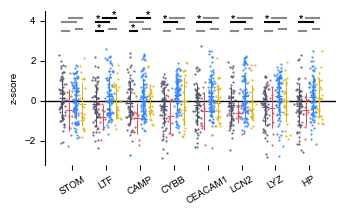

In [678]:
for t in ["tx", "txp"]: 
    zscore_plot_specific_genes(
        [
            # neutrophil granule proteins
            # secondary/specific
            "STOM",                             # GMP + preNeu + immNeu 
            "LTF", "CAMP", "CYBB", "CEACAM1",   # preNeu + immNeu
            "LCN2", "LYZ",                      # preNeu + immNeu + matNeu
            "HP",                               # matNeu
        ], 
        3.75,
        figname=os.path.join(FIGURE_DIR, f"neutrophil_granule_secondary_{t}_zscores.png"),
        tx_or_txp=t
    )

gene='MMP25'
pv_race=0.0685 pv_racem=0.8699
race='black' pv_mut=0.1968
race='white' pv_mut=0.3601
gene='ITGAM'
pv_race=0.7710 pv_racem=0.8508
race='black' pv_mut=0.3921
race='white' pv_mut=0.3635
gene='MMP8'
pv_race=0.5106 pv_racem=0.4990
race='black' pv_mut=0.7705
race='white' pv_mut=0.7657
gene='MMP9'
pv_race=0.0199 pv_racem=0.8740
race='black' pv_mut=0.2048
race='white' pv_mut=0.4159
gene='CFP'
pv_race=0.1224 pv_racem=0.1723
race='black' pv_mut=0.3138
race='white' pv_mut=0.7558
gene='ADAM8'
pv_race=0.3889 pv_racem=0.9679
race='black' pv_mut=0.7568
race='white' pv_mut=0.9952


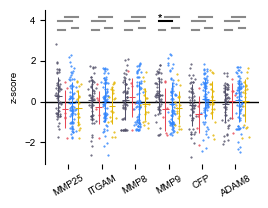

gene='MMP25'
pv_race=0.2130 pv_racem=0.4555
race='black' pv_mut=0.4822
race='white' pv_mut=0.4058
gene='ITGAM'
pv_race=0.0028 pv_racem=0.1364
race='black' pv_mut=0.3334
race='white' pv_mut=0.3831
gene='MMP8'
pv_race=0.0601 pv_racem=0.7935
race='black' pv_mut=0.6908
race='white' pv_mut=0.6562
gene='MMP9'
pv_race=0.0519 pv_racem=0.0842
race='black' pv_mut=0.4105
race='white' pv_mut=0.9156
gene='CFP'
pv_race=0.0006 pv_racem=0.0665
race='black' pv_mut=0.9345
race='white' pv_mut=0.9072
gene='ADAM8'
pv_race=0.0000 pv_racem=0.1389
race='black' pv_mut=0.9666
race='white' pv_mut=0.9419


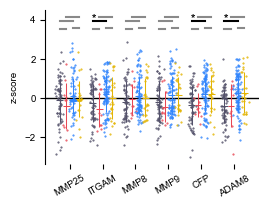

In [679]:
for t in ["tx", "txp"]: 
    zscore_plot_specific_genes(
        [
            # neutrophil granule proteins
            # tertiary/gelatinase
            "MMP25", "ITGAM",   # preNeu + immNeu + matNeu
            "MMP8", "MMP9",     # immNeu + matNeu
            "CFP", "ADAM8"  # matNeu

        ], 
        2.75,
        figname=os.path.join(FIGURE_DIR, f"neutrophil_granule_tertiary_{t}_zscores.png"),
        tx_or_txp=t
    )